# ViT Linear Probe Baseline — 5-Fold Cross-Validation

Frozen ViT features + Logistic Regression — no neural network training involved. This is a **linear probe** baseline: we fit a simple sklearn classifier on frozen pretrained features to measure how much useful information the representations already carry.

**Protocol:** Hold out 10% test set → extract features once (frozen backbone) → 5-fold CV on remaining 90% → each fold: StandardScaler + LogisticRegression → evaluate all folds on shared test set → ensemble by averaging predicted probabilities.

We test ViT-Base (google/vit-base-patch16-224) and ViT-Small (WinKawaks/vit-small-patch16-224).

**Binary labels:**
| Original Class | Binary Label |
|---|---|
| Melanoma | **Malignant** (1) |
| BCC | **Malignant** (1) |
| SCC | **Malignant** (1) |
| Actinic Keratosis | **Malignant** (1) |
| Malignant_Other | **Malignant** (1) |
| Melanocytic_Nevus | **Benign** (0) |
| Seborrheic_Keratosis | **Benign** (0) |
| Dermatofibroma | **Benign** (0) |
| Hemangioma | **Benign** (0) |
| Fibrous_Papule | **Benign** (0) |
| Other_Benign | **Benign** (0) |

## 1. Setup & Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, precision_recall_fscore_support, fbeta_score
)
from sklearn.preprocessing import StandardScaler

from utils import (
    BinaryDermoscopeSkinDataset, get_transforms, BINARY_MAP, CLASS_NAMES,
    find_optimal_threshold, compute_metrics, MIN_SENSITIVITY_TARGET
)

print("Imports complete.")

Imports complete.


In [2]:
# ── Configuration ──
IMAGES_DIR = "../DataCleaning/Images"
MANIFEST_PATH = "../DataCleaning/instances.csv"
BATCH_SIZE = 32  # Larger batch for feature extraction (no backprop)
NUM_CLASSES = 2
SEED = 42
K_FOLDS = 5

# Logistic regression config
LR_MAX_ITER = 1000
LR_C = 1.0
LR_CLASS_WEIGHT = 'balanced'

NUM_WORKERS = 0 if os.name == "nt" else min(os.cpu_count() or 8, 12)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"\n\U0001F52C LINEAR PROBE BASELINE — {K_FOLDS}-FOLD CROSS-VALIDATION")
print(f"  \u2022 Frozen ViT features + Logistic Regression")
print(f"  \u2022 {K_FOLDS} folds, ensemble by averaging probabilities")
print(f"  \u2022 Compare: ViT-Base, Small")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: cuda
PyTorch: 2.5.1+cu121

🔬 LINEAR PROBE BASELINE — 5-FOLD CROSS-VALIDATION
  • Frozen ViT features + Logistic Regression
  • 5 folds, ensemble by averaging probabilities
  • Compare: ViT-Base, Small

GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB


## 2. Transforms (No Augmentation)

In [3]:
# Use eval transform only (no augmentation for linear probe)
_, eval_transform = get_transforms(image_size=224, resize_size=256)

print("Transform created (center crop only, no augmentation)")

Transform created (center crop only, no augmentation)


## 3. Load Data & Test Holdout

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total instances: {len(manifest)}")
print(f"\nOriginal class distribution:")
print(manifest["cancer_type"].value_counts())

print(f"\nBinary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(manifest)
    print(f"  {name} ({lbl}): {count} ({pct:.1f}%)")

# 10% test holdout (same seed as fine-tuning experiments)
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss_test.split(manifest, manifest["binary_label"]))

trainval_manifest = manifest.iloc[trainval_idx].reset_index(drop=True)
test_manifest = manifest.iloc[test_idx].reset_index(drop=True)

print(f"\nStratified split: TrainVal {len(trainval_manifest)} | Test {len(test_manifest)}")

print(f"\nTrainVal binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (trainval_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(trainval_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

print(f"\nTest binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (test_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(test_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

Total instances: 906

Original class distribution:
cancer_type
BCC                     200
Melanocytic_Nevus       190
Other_Benign            138
SCC                     123
Seborrheic_Keratosis     79
Melanoma                 77
Actinic_Keratosis        63
Dermatofibroma           16
Hemangioma               10
Fibrous_Papule            6
Malignant_Other           4
Name: count, dtype: int64

Binary distribution:
  Benign (0): 439 (48.5%)
  Malignant (1): 467 (51.5%)

Stratified split: TrainVal 815 | Test 91

TrainVal binary distribution:
  Benign: 395 (48.5%)
  Malignant: 420 (51.5%)

Test binary distribution:
  Benign: 44 (48.4%)
  Malignant: 47 (51.6%)


## 4. Create Datasets & Loaders

In [5]:
trainval_dataset = BinaryDermoscopeSkinDataset(trainval_manifest, IMAGES_DIR, transform=eval_transform)
test_dataset = BinaryDermoscopeSkinDataset(test_manifest, IMAGES_DIR, transform=eval_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': True} if torch.cuda.is_available() else {}
trainval_loader = DataLoader(trainval_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Datasets: TrainVal {len(trainval_dataset)} | Test {len(test_dataset)}")
print(f"Batches:  TrainVal {len(trainval_loader)} | Test {len(test_loader)}")

Datasets: TrainVal 822 | Test 91
Batches:  TrainVal 26 | Test 3


## 5. Instance-to-Sample Mapping (for KFold)

In [6]:
# Build instance → sample index mapping for KFold splitting
# Each manifest row may have multiple dermoscope images (split by ";")
instance_to_samples = []
idx = 0
for _, row in trainval_manifest.iterrows():
    n_files = len(str(row["dscope_files"]).split(";"))
    instance_to_samples.append(list(range(idx, idx + n_files)))
    idx += n_files

print(f"Instance-to-sample mapping: {len(instance_to_samples)} instances -> {idx} samples")

Instance-to-sample mapping: 815 instances -> 822 samples


## 6. Load ViT Backbones (Base & Small)

In [7]:
print("Loading ViT backbones from HuggingFace...")

vit_base = ViTModel.from_pretrained("google/vit-base-patch16-224")
vit_small = ViTModel.from_pretrained("WinKawaks/vit-small-patch16-224")

for model in [vit_base, vit_small]:
    model.to(DEVICE).eval()
    for param in model.parameters():
        param.requires_grad = False

embed_dim_base = vit_base.config.hidden_size
embed_dim_small = vit_small.config.hidden_size

print(f"\n\u2713 ViT-Base  (google/vit-base-patch16-224): embed_dim={embed_dim_base}")
print(f"\u2713 ViT-Small (WinKawaks/vit-small-patch16-224): embed_dim={embed_dim_small}")
print(f"\nAll backbones frozen — feature extraction only")

Loading ViT backbones from HuggingFace...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ ViT-Base  (google/vit-base-patch16-224): embed_dim=768
✓ ViT-Small (WinKawaks/vit-small-patch16-224): embed_dim=384

All backbones frozen — feature extraction only


## 7. Feature Extraction Function

In [8]:
def extract_features(model, dataloader, desc="Extracting features"):
    """Extract frozen ViT [CLS] features from dataloader."""
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc=desc):
            imgs = imgs.to(DEVICE, non_blocking=True)
            outputs = model(imgs)
            # Extract CLS token: outputs.last_hidden_state[:, 0, :]
            feats = outputs.last_hidden_state[:, 0, :]
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("Feature extraction function defined.")

Feature extraction function defined.


## 8. Extract Features (Once Per Model)

Since backbones are frozen, features are deterministic — we extract once and reuse across all folds.

In [9]:
print("Extracting features from all models...\n")

# Base
base_tv_feats, tv_labels = extract_features(vit_base, trainval_loader, "Base: TrainVal")
base_test_feats, test_labels = extract_features(vit_base, test_loader, "Base: Test")
print(f"  Base TrainVal: {base_tv_feats.shape} | Test: {base_test_feats.shape}")

# Small
small_tv_feats, _ = extract_features(vit_small, trainval_loader, "Small: TrainVal")
small_test_feats, _ = extract_features(vit_small, test_loader, "Small: Test")
print(f"  Small TrainVal: {small_tv_feats.shape} | Test: {small_test_feats.shape}")

print(f"\n\u2713 All features extracted. Labels shape: {tv_labels.shape}")

Extracting features from all models...



Base: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Base: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Base TrainVal: (822, 768) | Test: (91, 768)


Small: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Small: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Small TrainVal: (822, 384) | Test: (91, 384)

✓ All features extracted. Labels shape: (822,)


## 9. Evaluation Utilities

In [10]:
def binary_model_evaluation(y_true, y_probs, class_names, title="",
                           threshold=None, min_sensitivity=MIN_SENSITIVITY_TARGET):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    if threshold is None:
        threshold, opt_sens, opt_spec = find_optimal_threshold(
            y_true, y_probs, min_sensitivity=min_sensitivity
        )
        print(f"\n\U0001F3AF Optimal threshold for \u2265{min_sensitivity*100:.0f}% sensitivity: {threshold:.3f}")
        print(f"   At this threshold: Sensitivity={opt_sens:.4f}, Specificity={opt_spec:.4f}")
    y_pred = (y_probs >= threshold).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, average='binary', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_true, y_probs)
    auc_pr = average_precision_score(y_true, y_probs)
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    print(f"  Classification Threshold: {threshold:.3f}")
    print(f"\n  SENSITIVITY METRICS (Malignant Detection):")
    print(f"    Sensitivity (Recall):  {sensitivity:.4f} {'✓' if sensitivity >= min_sensitivity else '✗'}")
    print(f"    PPV (Precision):       {ppv:.4f}")
    print(f"    F2 Score:              {f2:.4f}")
    print(f"\n  OVERALL METRICS:")
    print(f"    Accuracy:              {accuracy:.4f}")
    print(f"    Specificity:           {specificity:.4f}")
    print(f"    NPV:                   {npv:.4f}")
    print(f"    F1 Score:              {f1:.4f}")
    print(f"    AUC-ROC:               {auc_roc:.4f}")
    print(f"    AUC-PR:                {auc_pr:.4f}")
    print(f"{'='*70}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:<4} FP={fp:<4}")
    print(f"    FN={fn:<4} TP={tp:<4}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix\nThreshold={threshold:.3f}")
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC (AUC = {auc_roc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    y_pred_op = (y_probs >= threshold).astype(int)
    tn_op, fp_op, fn_op, tp_op = confusion_matrix(y_true, y_pred_op).ravel()
    fpr_op = fp_op / (fp_op + tn_op) if (fp_op + tn_op) > 0 else 0
    tpr_op = tp_op / (tp_op + fn_op) if (tp_op + fn_op) > 0 else 0
    axes[1].plot(fpr_op, tpr_op, 'ro', markersize=10,
                label=f'Operating Point\n(Sens={tpr_op:.3f})')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_probs)
    axes[2].plot(rec_curve, prec_curve, lw=2, color='green', label=f'PR (AP = {auc_pr:.4f})')
    axes[2].plot(tpr_op, ppv, 'ro', markersize=10,
                label=f'Operating Point\n(Rec={tpr_op:.3f}, Prec={ppv:.3f})')
    axes[2].set_xlabel("Recall (Sensitivity)")
    axes[2].set_ylabel("Precision (PPV)")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return {
        "threshold": threshold, "accuracy": accuracy, "precision": precision,
        "recall": recall, "sensitivity": sensitivity, "specificity": specificity,
        "ppv": ppv, "npv": npv, "f1": f1, "f2": f2,
        "auc_roc": auc_roc, "auc_pr": auc_pr,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }

print("Evaluation utilities defined.")

Evaluation utilities defined.


## 10. 5-Fold CV — ViT-Base

In [11]:
print(f"\n{'='*70}")
print(f"  ViT-BASE — {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

base_fold_val_metrics = []
base_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = base_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = base_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # StandardScaler
    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(fold_train_feats)
    fold_val_scaled = scaler.transform(fold_val_feats)
    fold_test_scaled = scaler.transform(base_test_feats)

    # Logistic Regression
    lr = LogisticRegression(
        max_iter=LR_MAX_ITER, C=LR_C, class_weight=LR_CLASS_WEIGHT,
        random_state=SEED, solver='lbfgs', verbose=0
    )
    lr.fit(fold_train_scaled, fold_train_labels)

    # Val metrics at optimal threshold
    val_probs = lr.predict_proba(fold_val_scaled)[:, 1]
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(fold_val_labels, val_probs, MIN_SENSITIVITY_TARGET)
    val_pred = (val_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)
    val_f2 = fbeta_score(fold_val_labels, val_pred, beta=2, average='binary', zero_division=0)

    base_fold_val_metrics.append({
        'fold': fold + 1, 'threshold': opt_thresh, 'auc_roc': val_auc,
        'sensitivity': val_sens, 'specificity': val_spec, 'accuracy': val_acc, 'f2': val_f2
    })

    # Test predictions
    test_probs = lr.predict_proba(fold_test_scaled)[:, 1]
    base_fold_test_probs.append(test_probs)

    print(f"  Opt Thresh={opt_thresh:.3f} | Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f} | F2={val_f2:.4f}")

    # ── Save best fold model (based on validation AUC) ──
    if fold == 0 or val_auc > max([r['auc_roc'] for r in base_fold_val_metrics[:-1]], default=0):
        best_base_fold_model_path = 'vit_base_linear_probe_best_fold.pth'
        torch.save({
            'model': lr,
            'scaler': scaler,
            'fold_idx': fold + 1,
            'val_auc': val_auc,
            'threshold': opt_thresh,
        }, best_base_fold_model_path)
        print(f"  ★ Saved as best fold model so far (val AUC: {val_auc:.4f})")

# Fold summary
fold_df = pd.DataFrame(base_fold_val_metrics)
print(f"\n{'='*70}")
print("BASE — Per-Fold Validation Results (at optimal threshold):")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean ± Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy', 'f2']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} ± {vals.std():.4f}")


  ViT-BASE — 5-Fold Cross-Validation

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7552 | Sens=0.8333 | Spec=0.5000 | Acc=0.6707 | F2=0.7848
  ★ Saved as best fold model so far (val AUC: 0.7552)

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6792 | Sens=0.8353 | Spec=0.3291 | Acc=0.5915 | F2=0.7651

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.8109 | Sens=0.9059 | Spec=0.5500 | Acc=0.7333 | F2=0.8499
  ★ Saved as best fold model so far (val AUC: 0.8109)

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7613 | Sens=0.8605 | Spec=0.4177 | Acc=0.6485 | F2=0.7974

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7349 | Sens=0.7647 | Spec=0.5316 | Acc=0.6524 | F2=0.7353

BASE — Per-Fold Validation Results (at optimal threshold):
 fold  threshold  auc_roc  sensitivity  specificity  accura

## 11. Base — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.8085, Specificity=0.2727

  ViT-Base (google/vit-base-patch16-224) Linear Probe — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.8085 ✗
    PPV (Precision):       0.5429
    F2 Score:              0.7364

  OVERALL METRICS:
    Accuracy:              0.5495
    Specificity:           0.2727
    NPV:                   0.5714
    F1 Score:              0.6496
    AUC-ROC:               0.6393
    AUC-PR:                0.6301

  Confusion Matrix:
    TN=12   FP=32  
    FN=9    TP=38  

              precision    recall  f1-score   support

      Benign       0.57      0.27      0.37        44
   Malignant       0.54      0.81      0.65        47

    accuracy                           0.55        91
   macro avg       0.56      0.54      0.51        91
weighted avg       

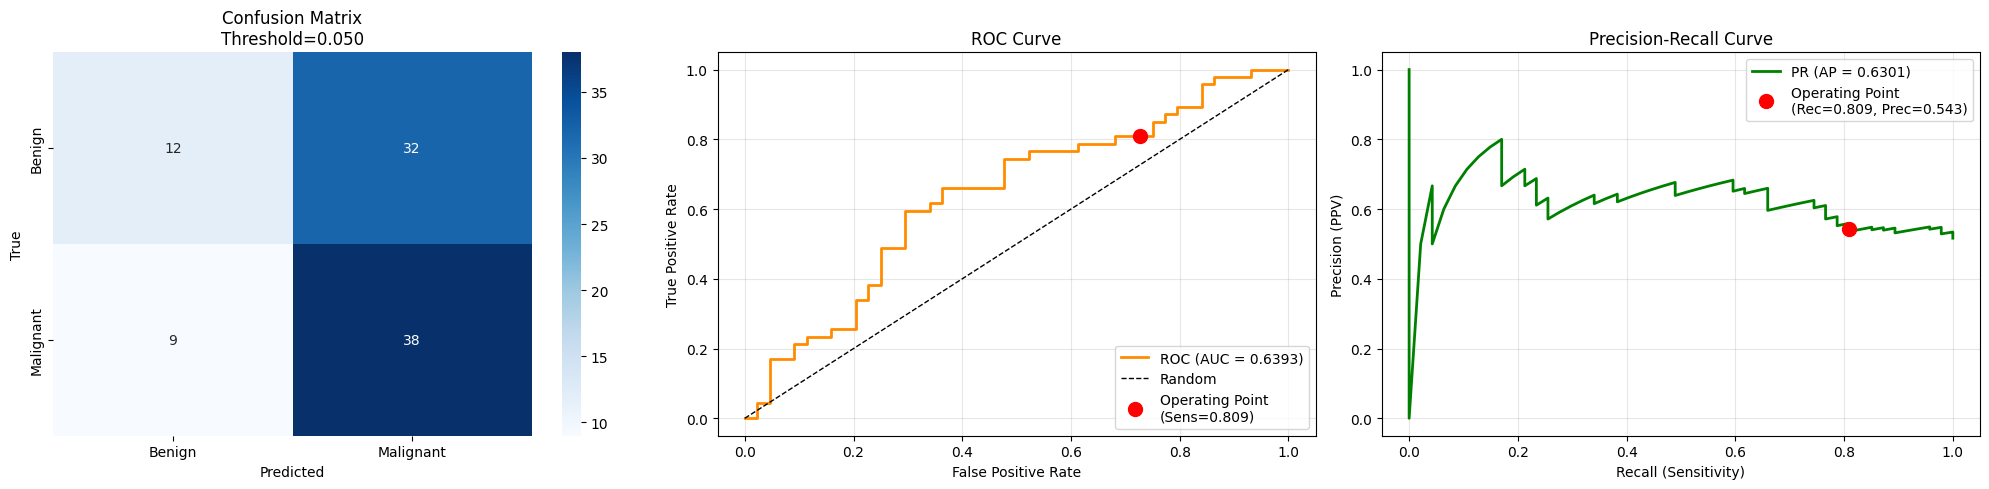

In [12]:
print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

base_ensemble_probs = np.mean(base_fold_test_probs, axis=0)

base_test_results = binary_model_evaluation(
    test_labels, base_ensemble_probs, CLASS_NAMES,
    title="ViT-Base (google/vit-base-patch16-224) Linear Probe — Ensemble Test",
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 12. 5-Fold CV — ViT-Small

In [13]:
print(f"\n{'='*70}")
print(f"  ViT-SMALL — {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

small_fold_val_metrics = []
small_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = small_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = small_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # StandardScaler
    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(fold_train_feats)
    fold_val_scaled = scaler.transform(fold_val_feats)
    fold_test_scaled = scaler.transform(small_test_feats)

    # Logistic Regression
    lr = LogisticRegression(
        max_iter=LR_MAX_ITER, C=LR_C, class_weight=LR_CLASS_WEIGHT,
        random_state=SEED, solver='lbfgs', verbose=0
    )
    lr.fit(fold_train_scaled, fold_train_labels)

    # Val metrics at optimal threshold
    val_probs = lr.predict_proba(fold_val_scaled)[:, 1]
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(fold_val_labels, val_probs, MIN_SENSITIVITY_TARGET)
    val_pred = (val_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)
    val_f2 = fbeta_score(fold_val_labels, val_pred, beta=2, average='binary', zero_division=0)

    small_fold_val_metrics.append({
        'fold': fold + 1, 'threshold': opt_thresh, 'auc_roc': val_auc,
        'sensitivity': val_sens, 'specificity': val_spec, 'accuracy': val_acc, 'f2': val_f2
    })

    # Test predictions
    test_probs = lr.predict_proba(fold_test_scaled)[:, 1]
    small_fold_test_probs.append(test_probs)

    print(f"  Opt Thresh={opt_thresh:.3f} | Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f} | F2={val_f2:.4f}")

    # ── Save best fold model (based on validation AUC) ──
    if fold == 0 or val_auc > max([r['auc_roc'] for r in small_fold_val_metrics[:-1]], default=0):
        best_small_fold_model_path = 'vit_small_linear_probe_best_fold.pth'
        torch.save({
            'model': lr,
            'scaler': scaler,
            'fold_idx': fold + 1,
            'val_auc': val_auc,
            'threshold': opt_thresh,
        }, best_small_fold_model_path)
        print(f"  ★ Saved as best fold model so far (val AUC: {val_auc:.4f})")

# Fold summary
fold_df = pd.DataFrame(small_fold_val_metrics)
print(f"\n{'='*70}")
print("SMALL — Per-Fold Validation Results (at optimal threshold):")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean ± Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy', 'f2']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} ± {vals.std():.4f}")


  ViT-SMALL — 5-Fold Cross-Validation

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6778 | Sens=0.8929 | Spec=0.3875 | Acc=0.6463 | F2=0.8152
  ★ Saved as best fold model so far (val AUC: 0.6778)

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6975 | Sens=0.8000 | Spec=0.4430 | Acc=0.6280 | F2=0.7522
  ★ Saved as best fold model so far (val AUC: 0.6975)

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7547 | Sens=0.8824 | Spec=0.5500 | Acc=0.7212 | F2=0.8315
  ★ Saved as best fold model so far (val AUC: 0.7547)

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.6326 | Sens=0.7791 | Spec=0.3544 | Acc=0.5758 | F2=0.7251

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6657 | Sens=0.8118 | Spec=0.4810 | Acc=0.6524 | F2=0.7667

SMALL — Per-Fold Validation Results (at optimal threshold):
 fo

## 13. Small — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.8723, Specificity=0.2273

  ViT-Small (WinKawaks/vit-small-patch16-224) Linear Probe — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.8723 ✗
    PPV (Precision):       0.5467
    F2 Score:              0.7795

  OVERALL METRICS:
    Accuracy:              0.5604
    Specificity:           0.2273
    NPV:                   0.6250
    F1 Score:              0.6721
    AUC-ROC:               0.6059
    AUC-PR:                0.6010

  Confusion Matrix:
    TN=10   FP=34  
    FN=6    TP=41  

              precision    recall  f1-score   support

      Benign       0.62      0.23      0.33        44
   Malignant       0.55      0.87      0.67        47

    accuracy                           0.56        91
   macro avg       0.59      0.55      0.50        91
weighted avg  

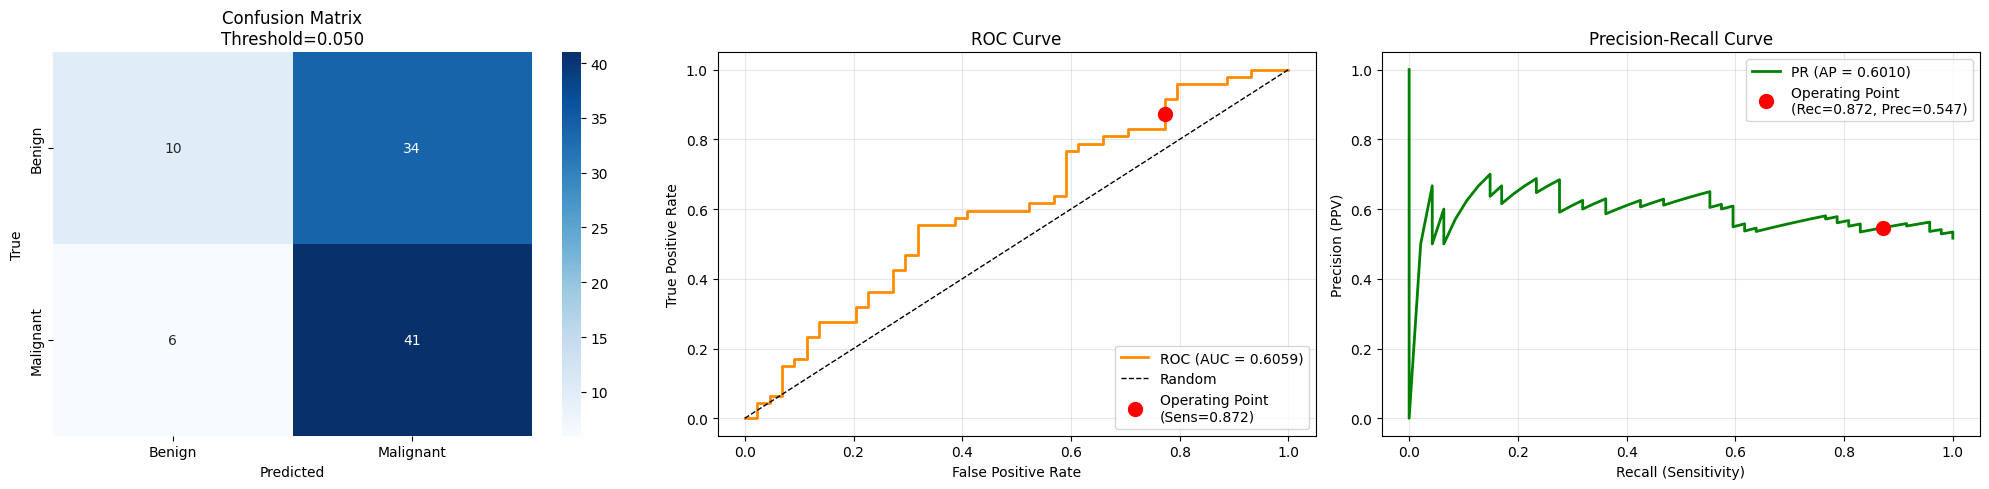

In [14]:
print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

small_ensemble_probs = np.mean(small_fold_test_probs, axis=0)

small_test_results = binary_model_evaluation(
    test_labels, small_ensemble_probs, CLASS_NAMES,
    title="ViT-Small (WinKawaks/vit-small-patch16-224) Linear Probe — Ensemble Test",
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 14. Final Summary — Model Comparison

In [15]:
print("\n" + "="*80)
print("  ViT LINEAR PROBE — FINAL COMPARISON (Ensemble Test Results)")
print("="*80)

summary_data = {
    'Model': ['ViT-Base', 'ViT-Small'],
    'Threshold': [base_test_results['threshold'], small_test_results['threshold']],
    'AUC-ROC': [base_test_results['auc_roc'], small_test_results['auc_roc']],
    'Sensitivity': [base_test_results['sensitivity'], small_test_results['sensitivity']],
    'Specificity': [base_test_results['specificity'], small_test_results['specificity']],
    'Accuracy': [base_test_results['accuracy'], small_test_results['accuracy']],
    'F1': [base_test_results['f1'], small_test_results['f1']],
    'F2': [base_test_results['f2'], small_test_results['f2']],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "="*80)
print(f"  Target Sensitivity: ≥{MIN_SENSITIVITY_TARGET*100:.0f}%")
print("="*80)

# Highlight best model
if base_test_results['auc_roc'] > small_test_results['auc_roc']:
    print("\n\u2192 ViT-Base achieves higher AUC-ROC on test set.")
else:
    print("\n\u2192 ViT-Small achieves higher AUC-ROC on test set.")


  ViT LINEAR PROBE — FINAL COMPARISON (Ensemble Test Results)
    Model  Threshold  AUC-ROC  Sensitivity  Specificity  Accuracy     F1     F2
 ViT-Base     0.0500   0.6393       0.8085       0.2727    0.5495 0.6496 0.7364
ViT-Small     0.0500   0.6059       0.8723       0.2273    0.5604 0.6721 0.7795

  Target Sensitivity: ≥95%

→ ViT-Base achieves higher AUC-ROC on test set.
